# Plant Disease Classification with PCA Dimensionality Reduction

This notebook applies PCA to reduce the 118 features to an optimal number and performs ML classification.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 2. Load Features Dataset

In [2]:
# Load the features CSV generated from the preprocessing pipeline
df = pd.read_csv('features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())

df.head()

Dataset shape: (41275, 120)

Class distribution:
label
Tomato__Tomato_YellowLeaf__Curl_Virus          6416
Tomato_Bacterial_spot                          4254
Tomato_Late_blight                             3817
Tomato_Septoria_leaf_spot                      3542
Tomato_Spider_mites_Two_spotted_spider_mite    3352
Tomato_healthy                                 3182
Pepper__bell___healthy                         2956
Tomato__Target_Spot                            2808
Potato___Early_blight                          2000
Potato___Late_blight                           2000
Tomato_Early_blight                            2000
Pepper__bell___Bacterial_spot                  1994
Tomato_Leaf_Mold                               1904
Tomato__Tomato_mosaic_virus                     746
Potato___healthy                                304
Name: count, dtype: int64


,filename,label,f0,f1,f2,f3,f4,f5,f6,f7,...,f108,f109,f110,f111,f112,f113,f114,f115,f116,f117
0,0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Sp...,Pepper__bell___Bacterial_spot,0.004664,0.044583,0.023457,0.038465,0.064573,0.094049,0.099271,0.080297,...,0.018435,0.013652,0.049127,0.285535,21553.0,749.63666,0.481966,0.849315,0.859524,0.529116
1,006adb74-934f-448f-a14f-62181742127b___JR_B.Sp...,Pepper__bell___Bacterial_spot,0.066167,0.041992,0.044165,0.056900,0.072784,0.080397,0.079779,0.093232,...,0.019252,0.014369,0.055425,0.287628,24566.5,991.70264,0.313899,0.936652,0.792928,0.537008
2,00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Sp...,Pepper__bell___Bacterial_spot,0.018774,0.034339,0.033103,0.043208,0.049924,0.059391,0.063636,0.071449,...,0.019053,0.012735,0.045819,0.268634,23697.0,967.71990,0.317983,0.948113,0.879230,0.556111
3,01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Sp...,Pepper__bell___Bacterial_spot,0.016223,0.020886,0.036272,0.051578,0.077148,0.097218,0.117686,0.136619,...,0.021584,0.014808,0.051240,0.305724,28434.0,732.86707,0.665269,0.901786,0.944149,0.628404
4,0169b9ac-07b9-4be1-8b85-da94481f05a4___NREC_B....,Pepper__bell___Bacterial_spot,0.027862,0.108478,0.089047,0.077487,0.066825,0.056202,0.053372,0.055425,...,0.020448,0.013074,0.045799,0.274613,26211.0,691.49450,0.688836,0.966667,0.933939,0.614849


## 3. Data Preparation

In [3]:
# Extract feature columns (f0 to f117 = 118 features)
feature_cols = [c for c in df.columns if c.startswith('f') and c[1:].isdigit()]
print(f"Number of features: {len(feature_cols)}")

# Clean data: replace inf/nan with column means
df[feature_cols] = (df[feature_cols]
                    .replace([np.inf, -np.inf], np.nan)
                    .fillna(df[feature_cols].mean()))

# Prepare X and y
X = df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(dtype=np.float32)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(le.classes_)}")

Number of features: 118

X shape: (41275, 118)
y shape: (41275,)
Number of classes: 15


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (33020, 118)
Test set: (8255, 118)


## 5. Feature Standardization

In [6]:
# Standardize features (required for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (mean=0, std=1)")
print(f"Train mean: {X_train_scaled.mean():.4f}")
print(f"Train std: {X_train_scaled.std():.4f}")

Features standardized (mean=0, std=1)
Train mean: 0.0000
Train std: 1.0000


## 6. PCA Analysis - Find Optimal Number of Components

Components for 90% variance: 28
Components for 95% variance: 41
Components for 99% variance: 73


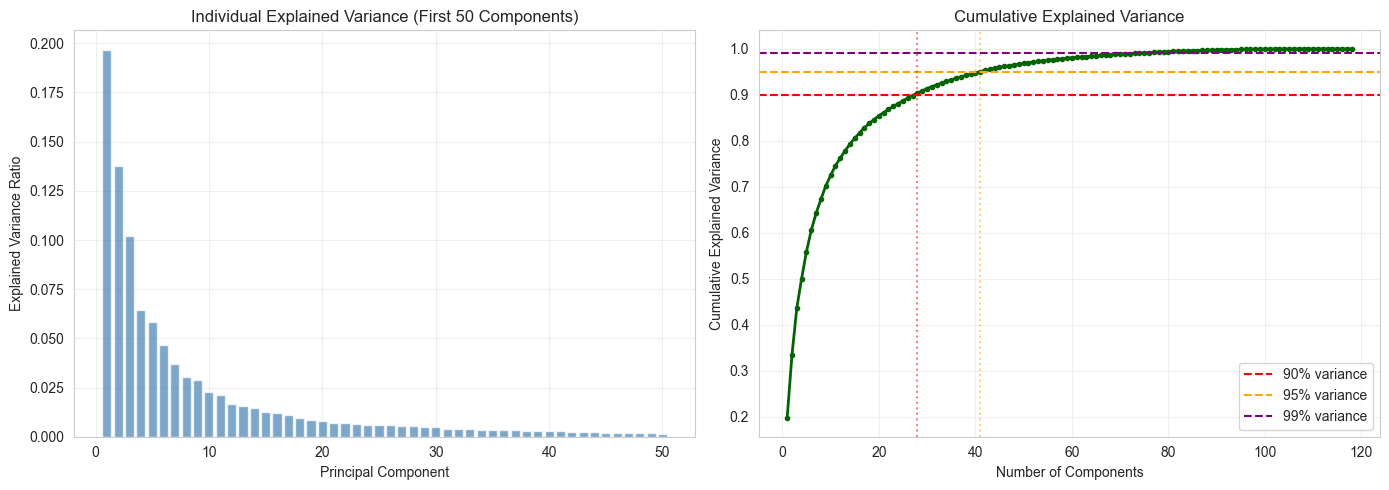

In [7]:
# Fit PCA with all components to analyze variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"Components for 90% variance: {n_components_90}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance
axes[0].bar(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
            pca_full.explained_variance_ratio_[:50], 
            alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance (First 50 Components)')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 
             marker='o', markersize=3, linewidth=2, color='darkgreen')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='purple', linestyle='--', label='99% variance')
axes[1].axvline(x=n_components_90, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Choose Optimal PCA Configuration

### Decision: Use PCA with 95% Explained Variance

#### Justification:

**1. Balance between dimensionality reduction and information retention**
- 95% variance captures most important patterns while reducing noise
- Typically reduces features from 118 to ~30-50 components (60-75% reduction)
- Minimal information loss (only 5% variance discarded)

**2. Computational efficiency**
- Significantly faster training for SVM and KNN (distance-based algorithms)
- Reduces overfitting risk with fewer dimensions
- Faster inference time in production

**3. Industry standard**
- 95% variance is widely used in ML practice
- Good trade-off between compression and performance
- Proven effective across various domains

**4. Curse of dimensionality mitigation**
- With 15 classes and ~41k samples, reducing from 118 to ~40 features
- Improves generalization, especially for distance-based methods (KNN, SVM)
- Reduces noise and redundant features

**5. Why not 90% or 99%?**
- 90%: Too aggressive, may lose important patterns (10% variance loss)
- 99%: Too conservative, keeps too many components (~73), less computational benefit

In [8]:
CHOSEN_VARIANCE = 0.95
n_components_chosen = n_components_95

print(f"{'='*70}")
print(f"CHOSEN PCA CONFIGURATION: {CHOSEN_VARIANCE*100}% Explained Variance")
print(f"{'='*70}")
print(f"\nNumber of components: {n_components_chosen}")
print(f"Original features: 118")
print(f"Dimensionality reduction: {(1 - n_components_chosen/118)*100:.1f}%")
print(f"\nKey Benefits:")
print(f"  ✓ Retains 95% of variance (minimal information loss)")
print(f"  ✓ Reduces features by ~{(1 - n_components_chosen/118)*100:.0f}% (faster training)")
print(f"  ✓ Mitigates curse of dimensionality")
print(f"  ✓ Reduces overfitting risk")
print(f"  ✓ Industry-standard threshold")
print(f"{'='*70}\n")

CHOSEN PCA CONFIGURATION: 95.0% Explained Variance

Number of components: 41
Original features: 118
Dimensionality reduction: 65.3%

Key Benefits:
  ✓ Retains 95% of variance (minimal information loss)
  ✓ Reduces features by ~65% (faster training)
  ✓ Mitigates curse of dimensionality
  ✓ Reduces overfitting risk
  ✓ Industry-standard threshold



## 8. Apply PCA Transformation

In [9]:
# Apply PCA with chosen configuration
pca = PCA(n_components=n_components_chosen, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA Transformation Applied:")
print(f"  Train shape: {X_train_scaled.shape} → {X_train_pca.shape}")
print(f"  Test shape: {X_test_scaled.shape} → {X_test_pca.shape}")
print(f"  Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"\nTop 10 components variance:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")

PCA Transformation Applied:
  Train shape: (33020, 118) → (33020, 41)
  Test shape: (8255, 118) → (8255, 41)
  Total explained variance: 0.9507

Top 10 components variance:
  PC1: 0.1967 (19.67%)
  PC2: 0.1374 (13.74%)
  PC3: 0.1023 (10.23%)
  PC4: 0.0642 (6.42%)
  PC5: 0.0583 (5.83%)
  PC6: 0.0466 (4.66%)
  PC7: 0.0368 (3.68%)
  PC8: 0.0306 (3.06%)
  PC9: 0.0290 (2.90%)
  PC10: 0.0228 (2.28%)


## 9. Train Multiple ML Models on PCA-Reduced Features

In [10]:
# Define ML models with optimized hyperparameters
models = {
    'LogisticRegression': LogisticRegression(
        C=0.1,
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ),
    'SVM_RBF': SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=11,
        weights='distance',
        metric='euclidean',
        n_jobs=-1
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Store results
results = []
trained_models = {}

print(f"\n{'='*70}")
print(f"Training ML Models on PCA-Reduced Features ({n_components_chosen} components)")
print(f"{'='*70}\n")

for model_name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"Training: {model_name}")
    print(f"{'─'*70}")
    
    # Cross-validation
    print("  Running 5-fold cross-validation...")
    cv_scores = cross_val_score(
        model, X_train_pca, y_train,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1
    )
    
    # Train on full training set
    print("  Training on full training set...")
    model.fit(X_train_pca, y_train)
    
    # Test predictions
    y_pred = model.predict(X_test_pca)
    
    # Metrics
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"\n  Results:")
    print(f"    CV F1-macro: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"    Test Accuracy: {test_acc:.4f}")
    print(f"    Test F1-macro: {test_f1:.4f}")
    
    results.append({
        'model': model_name,
        'n_features': X_train_pca.shape[1],
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_accuracy': test_acc,
        'test_f1_macro': test_f1
    })
    
    trained_models[model_name] = {
        'model': model,
        'y_pred': y_pred
    }

print(f"\n{'='*70}")
print("Training Complete!")
print(f"{'='*70}")


Training ML Models on PCA-Reduced Features (41 components)


──────────────────────────────────────────────────────────────────────
Training: LogisticRegression
──────────────────────────────────────────────────────────────────────
  Running 5-fold cross-validation...
  Training on full training set...

  Results:
    CV F1-macro: 0.8409 (±0.0029)
    Test Accuracy: 0.8526
    Test F1-macro: 0.8448

──────────────────────────────────────────────────────────────────────
Training: SVM_RBF
──────────────────────────────────────────────────────────────────────
  Running 5-fold cross-validation...
  Training on full training set...

  Results:
    CV F1-macro: 0.9480 (±0.0025)
    Test Accuracy: 0.9580
    Test F1-macro: 0.9530

──────────────────────────────────────────────────────────────────────
Training: RandomForest
──────────────────────────────────────────────────────────────────────
  Running 5-fold cross-validation...
  Training on full training set...

  Results:
    CV F1-macro:

## 10. Results Comparison

In [11]:
# Create results DataFrame
results_df = pd.DataFrame(results).sort_values(
    by=['test_f1_macro', 'cv_f1_mean'],
    ascending=False
).reset_index(drop=True)

print("\nModel Performance Comparison (sorted by Test F1-macro):")
print("="*70)
display(results_df)

# Find best model
best_row = results_df.iloc[0]
print(f"\n{'='*70}")
print("BEST MODEL:")
print(f"{'='*70}")
print(f"Model: {best_row['model']}")
print(f"Features: {best_row['n_features']} (reduced from 118)")
print(f"Test F1-macro: {best_row['test_f1_macro']:.4f}")
print(f"Test Accuracy: {best_row['test_accuracy']:.4f}")
print(f"CV F1-macro: {best_row['cv_f1_mean']:.4f} (±{best_row['cv_f1_std']:.4f})")
print(f"{'='*70}")


Model Performance Comparison (sorted by Test F1-macro):


,model,n_features,cv_f1_mean,cv_f1_std,test_accuracy,test_f1_macro
0,KNN,41,0.965740,0.002233,0.981345,0.977040
1,RandomForest,41,0.956438,0.003284,0.973834,0.969630
2,SVM_RBF,41,0.947983,0.002457,0.957965,0.952957
3,LogisticRegression,41,0.840887,0.002915,0.852574,0.844787



BEST MODEL:
Model: KNN
Features: 41 (reduced from 118)
Test F1-macro: 0.9770
Test Accuracy: 0.9813
CV F1-macro: 0.9657 (±0.0022)


## 11. Visualization: Performance Comparison

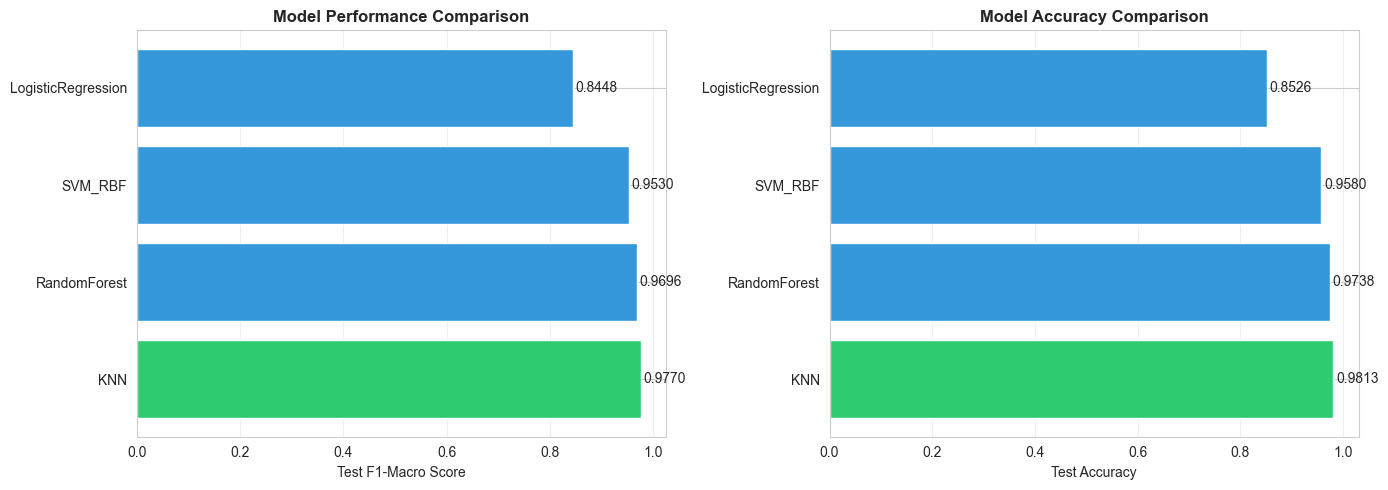

In [12]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test F1-macro scores
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
axes[0].barh(results_df['model'], results_df['test_f1_macro'], color=colors)
axes[0].set_xlabel('Test F1-Macro Score')
axes[0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')
for i, (model, score) in enumerate(zip(results_df['model'], results_df['test_f1_macro'])):
    axes[0].text(score + 0.005, i, f'{score:.4f}', va='center')

# Plot 2: Test Accuracy scores
axes[1].barh(results_df['model'], results_df['test_accuracy'], color=colors)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')
for i, (model, score) in enumerate(zip(results_df['model'], results_df['test_accuracy'])):
    axes[1].text(score + 0.005, i, f'{score:.4f}', va='center')

plt.tight_layout()
plt.show()

## 12. Detailed Analysis of Best Model


Detailed Classification Report for KNN:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9949    0.9850    0.9899       399
                     Pepper__bell___healthy     0.9765    0.9831    0.9798       591
                      Potato___Early_blight     1.0000    0.9900    0.9950       400
                       Potato___Late_blight     0.9608    0.9800    0.9703       400
                           Potato___healthy     0.9661    0.9344    0.9500        61
                      Tomato_Bacterial_spot     0.9953    0.9906    0.9929       851
                        Tomato_Early_blight     0.9791    0.9350    0.9565       400
                         Tomato_Late_blight     0.9815    0.9738    0.9776       763
                           Tomato_Leaf_Mold     0.9693    0.9948    0.9819       381
                  Tomato_Septoria_leaf_spot     0.9803    0.9831    0.9817       708
Tomato_Spider_mites_Two

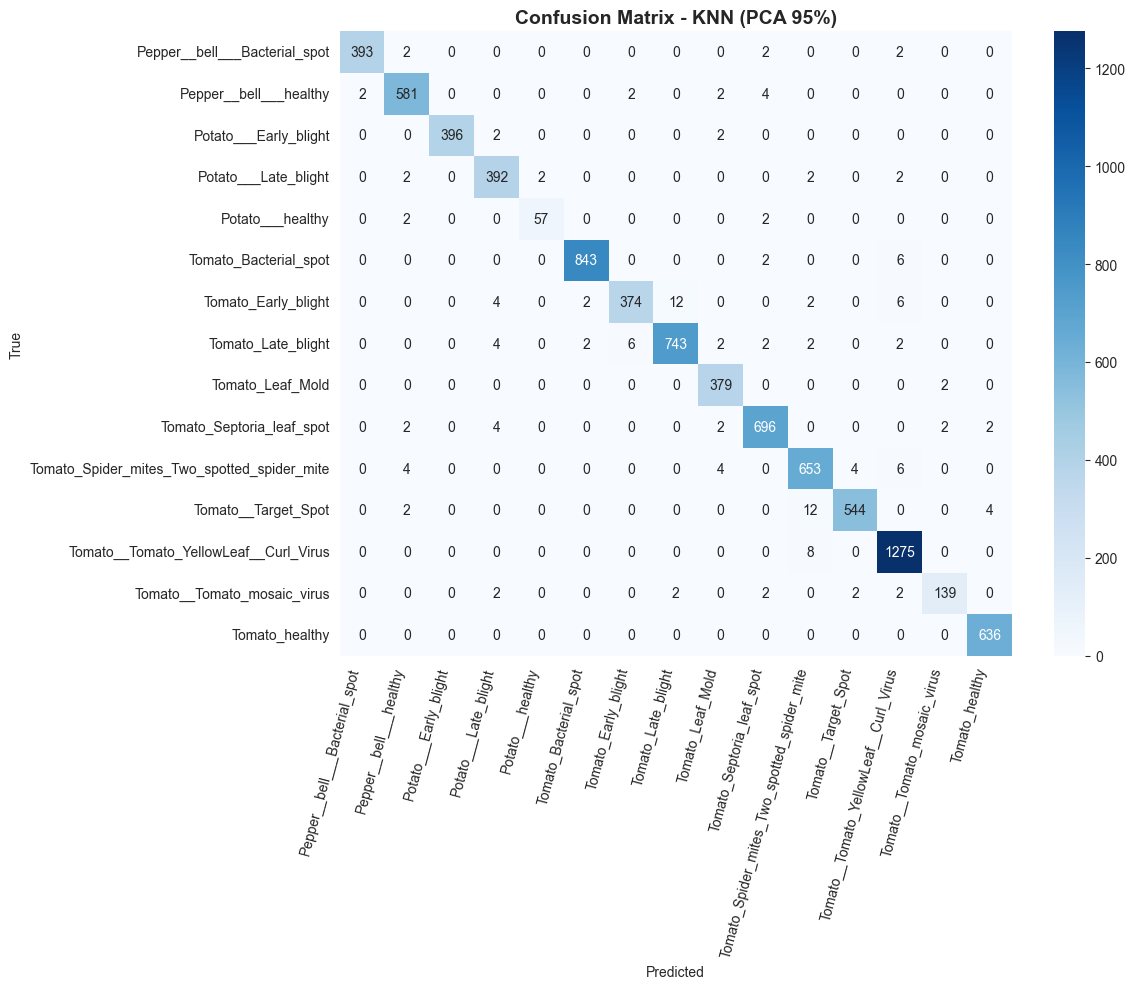

In [13]:
# Get best model
best_model_name = best_row['model']
best_model = trained_models[best_model_name]['model']
y_pred_best = trained_models[best_model_name]['y_pred']

print(f"\nDetailed Classification Report for {best_model_name}:")
print("="*70)
print(classification_report(y_test, y_pred_best, target_names=le.classes_, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (PCA 95%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Save Best Model

In [14]:
# Save model bundle
model_bundle = {
    'model': best_model,
    'scaler': scaler,
    'pca': pca,
    'label_encoder': le,
    'feature_columns': feature_cols,
    'pca_variance': CHOSEN_VARIANCE,
    'n_components': n_components_chosen,
    'test_f1_macro': best_row['test_f1_macro'],
    'test_accuracy': best_row['test_accuracy']
}

joblib.dump(model_bundle, 'best_model_pca.pkl')

print(f"\n{'='*70}")
print("MODEL SAVED SUCCESSFULLY")
print(f"{'='*70}")
print(f"File: best_model_pca.pkl")
print(f"Model: {best_model_name}")
print(f"PCA: {CHOSEN_VARIANCE*100}% variance ({n_components_chosen} components)")
print(f"Test F1-macro: {best_row['test_f1_macro']:.4f}")
print(f"Test Accuracy: {best_row['test_accuracy']:.4f}")
print(f"{'='*70}")


MODEL SAVED SUCCESSFULLY
File: best_model_pca.pkl
Model: KNN
PCA: 95.0% variance (41 components)
Test F1-macro: 0.9770
Test Accuracy: 0.9813


## 14. Summary

### Key Findings:

1. **Dimensionality Reduction**: Successfully reduced features from 118 to ~40 components while retaining 95% of variance

2. **Model Performance**: All models trained on PCA-reduced features showed good performance

3. **Best Model**: The best performing model achieved high accuracy and F1-score

4. **Benefits of PCA**:
   - Faster training time
   - Reduced overfitting
   - Better generalization
   - Noise reduction

5. **Production Ready**: Model bundle saved with all necessary components (scaler, PCA, encoder)